In [ ]:
import pandas as pd

# 1. 파일 불러오기 (인코딩은 상황에 맞게 'euc-kr' 또는 'utf-8' 선택)
# 구글 시트에서 저장한 파일이라면 보통 'utf-8'입니다.
df = pd.read_csv('data/real_estate_clean_v2.csv', encoding='cp949', parse_dates=["계약일"])
df

C:\Users\gorhk\AppData\Local\Temp\ipykernel_11588\1380554432.py:5: DtypeWarning: Columns (19,20) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('data/real_estate_total.csv', encoding='cp949', parse_dates=["계약일"])


,접수연도,자치구코드,자치구명,법정동코드,법정동명,지번구분,지번구분명,본번,부번,건물명,...,물건금액(만원),건물면적(㎡),토지면적(㎡),층,권리구분,취소일,건축년도,건물용도,신고구분,신고한_개업공인중개사_시군구명
0,2018,11500,강서구,10300,화곡동,1.0,대지,1159.0,0.0,"우장산아이파크,이편한세상",...,95000,101.65,NaN,10.0,NaN,NaN,2008.0,아파트,NaN,NaN
1,2018,11410,서대문구,11200,대현동,1.0,대지,144.0,0.0,럭키대현,...,70000,83.38,NaN,10.0,NaN,NaN,1999.0,아파트,NaN,NaN
2,2018,11590,동작구,10700,사당동,1.0,대지,169.0,32.0,현대,...,49500,51.66,NaN,10.0,NaN,NaN,1991.0,아파트,NaN,NaN
3,2018,11350,노원구,10500,상계동,1.0,대지,1380.0,4.0,초산빌라,...,16000,41.37,18.38,1.0,NaN,NaN,1996.0,연립다세대,NaN,NaN
4,2018,11380,은평구,11000,증산동,1.0,대지,189.0,63.0,궁전맨션(189-63),...,43000,54.34,27.17,2.0,NaN,NaN,1992.0,연립다세대,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
833609,2024,11530,구로구,10700,개봉동,1.0,대지,170.0,33.0,금석연립(170-33),...,9190,53.61,124.00,1.0,NaN,20240207.0,1981.0,연립다세대,중개거래,서울 강남구
833610,2024,11530,구로구,10700,개봉동,1.0,대지,170.0,33.0,금석연립(170-33),...,9190,53.61,124.00,1.0,NaN,20240207.0,1981.0,연립다세대,중개거래,서울 강남구
833611,2024,11530,구로구,10700,개봉동,1.0,대지,170.0,33.0,금석연립(170-33),...,9740,53.61,124.00,2.0,NaN,20240207.0,1981.0,연립다세대,중개거래,서울 강남구
833612,2024,11440,마포구,11000,노고산동,NaN,NaN,NaN,NaN,NaN,...,195000,157.45,116.70,NaN,NaN,20240417.0,1988.0,단독다가구,NaN,NaN


In [2]:
import matplotlib.pyplot as plt
import platform

# 1. 한글 폰트 설정
if platform.system() == 'Windows':
    plt.rc('font', family='Malgun Gothic')  # 윈도우: 맑은 고딕
elif platform.system() == 'Darwin': 
    plt.rc('font', family='AppleGothic')    # 맥: 애플고딕
else:
    plt.rc('font', family='NanumGothic')    # 리눅스 등: 나눔고딕

# 2. 마이너스 기호 깨짐 방지
plt.rc('axes', unicode_minus=False)

# 3. 해상도 선명하게 (선택사항)
# from IPython.display import set_matplotlib_formats
# set_matplotlib_formats('retina')

In [3]:
# 2. 변경할 컬럼 매핑 딕셔너리 생성
# { "기존 한글명": "변경할 영어명" }
rename_dict = {
    "접수연도": "RCPT_YR",
    "자치구코드": "CGG_CD",
    "자치구명": "CGG_NM",
    "법정동코드": "STDG_CD",
    "법정동명": "STDG_NM",
    "지번구분": "LOTNO_SE",
    "지번구분명": "LOTNO_SE_NM",
    "본번": "MNO",
    "부번": "SNO",
    "건물명": "BLDG_NM",
    "계약일": "CTRT_DAY",
    "물건금액(만원)": "THING_AMT",
    "건물면적(㎡)": "ARCH_AREA",
    "토지면적(㎡)": "LAND_AREA",
    "층": "FLR",
    "권리구분": "RGHT_SE",
    "취소일": "RTRCN_DAY",
    "건축년도": "ARCH_YR",
    "건물용도": "BLDG_USG",
    "신고구분": "DCLR_SE",
    "신고한_개업공인중개사_시군구명": "OPBIZ_RESTAGNT_SGG_NM"
}

# 3. 컬럼명 변경 적용
df = df.rename(columns=rename_dict)

# 4. 제거할 열 리스트 (여기 적힌 열들이 삭제됩니다)
excluded_columns = [
    "RCPT_YR", "LOTNO_SE_NM", "MNO", "SNO", "OPBIZ_RESTAGNT_SGG_NM"
]
# 열 삭제 실행 (axis=1은 열을 의미합니다)
df_final = df.drop(columns=excluded_columns)

# 5. 결과 저장 (DBeaver 업로드용 UTF-8)
df_final.to_csv('data/real_estate_total_edit.csv', index=False, encoding='cp949')


In [4]:
df = pd.read_csv('data/real_estate_total_edit.csv', encoding='cp949', parse_dates=["CTRT_DAY"])
df

C:\Users\gorhk\AppData\Local\Temp\ipykernel_11588\2835427283.py:1: DtypeWarning: Columns (15) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('data/real_estate_total_edit.csv', encoding='cp949', parse_dates=["CTRT_DAY"])


,CGG_CD,CGG_NM,STDG_CD,STDG_NM,LOTNO_SE,BLDG_NM,CTRT_DAY,THING_AMT,ARCH_AREA,LAND_AREA,FLR,RGHT_SE,RTRCN_DAY,ARCH_YR,BLDG_USG,DCLR_SE
0,11500,강서구,10300,화곡동,1.0,"우장산아이파크,이편한세상",2019-04-25,95000,101.65,NaN,10.0,NaN,NaN,2008.0,아파트,NaN
1,11410,서대문구,11200,대현동,1.0,럭키대현,2019-03-16,70000,83.38,NaN,10.0,NaN,NaN,1999.0,아파트,NaN
2,11590,동작구,10700,사당동,1.0,현대,2019-02-21,49500,51.66,NaN,10.0,NaN,NaN,1991.0,아파트,NaN
3,11350,노원구,10500,상계동,1.0,초산빌라,2019-01-21,16000,41.37,18.38,1.0,NaN,NaN,1996.0,연립다세대,NaN
4,11380,은평구,11000,증산동,1.0,궁전맨션(189-63),2019-01-03,43000,54.34,27.17,2.0,NaN,NaN,1992.0,연립다세대,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
833609,11530,구로구,10700,개봉동,1.0,금석연립(170-33),2022-07-08,9190,53.61,124.00,1.0,NaN,20240207.0,1981.0,연립다세대,중개거래
833610,11530,구로구,10700,개봉동,1.0,금석연립(170-33),2022-07-08,9190,53.61,124.00,1.0,NaN,20240207.0,1981.0,연립다세대,중개거래
833611,11530,구로구,10700,개봉동,1.0,금석연립(170-33),2022-07-08,9740,53.61,124.00,2.0,NaN,20240207.0,1981.0,연립다세대,중개거래
833612,11440,마포구,11000,노고산동,NaN,NaN,2021-07-19,195000,157.45,116.70,NaN,NaN,20240417.0,1988.0,단독다가구,NaN


In [5]:
# 앞으로 사용할 데이터프레임 새로 생성
df = df.copy()
df

,CGG_CD,CGG_NM,STDG_CD,STDG_NM,LOTNO_SE,BLDG_NM,CTRT_DAY,THING_AMT,ARCH_AREA,LAND_AREA,FLR,RGHT_SE,RTRCN_DAY,ARCH_YR,BLDG_USG,DCLR_SE
0,11500,강서구,10300,화곡동,1.0,"우장산아이파크,이편한세상",2019-04-25,95000,101.65,NaN,10.0,NaN,NaN,2008.0,아파트,NaN
1,11410,서대문구,11200,대현동,1.0,럭키대현,2019-03-16,70000,83.38,NaN,10.0,NaN,NaN,1999.0,아파트,NaN
2,11590,동작구,10700,사당동,1.0,현대,2019-02-21,49500,51.66,NaN,10.0,NaN,NaN,1991.0,아파트,NaN
3,11350,노원구,10500,상계동,1.0,초산빌라,2019-01-21,16000,41.37,18.38,1.0,NaN,NaN,1996.0,연립다세대,NaN
4,11380,은평구,11000,증산동,1.0,궁전맨션(189-63),2019-01-03,43000,54.34,27.17,2.0,NaN,NaN,1992.0,연립다세대,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
833609,11530,구로구,10700,개봉동,1.0,금석연립(170-33),2022-07-08,9190,53.61,124.00,1.0,NaN,20240207.0,1981.0,연립다세대,중개거래
833610,11530,구로구,10700,개봉동,1.0,금석연립(170-33),2022-07-08,9190,53.61,124.00,1.0,NaN,20240207.0,1981.0,연립다세대,중개거래
833611,11530,구로구,10700,개봉동,1.0,금석연립(170-33),2022-07-08,9740,53.61,124.00,2.0,NaN,20240207.0,1981.0,연립다세대,중개거래
833612,11440,마포구,11000,노고산동,NaN,NaN,2021-07-19,195000,157.45,116.70,NaN,NaN,20240417.0,1988.0,단독다가구,NaN


In [6]:
# 날짜 컬럼을 datetime 형식으로 변환 (필수!)
df['CTRT_DAY'] = pd.to_datetime(df['CTRT_DAY'])

# 계약 연도 컬럼 새로 생성
df['CTRT_YEAR'] = df['CTRT_DAY'].dt.year 

# 계약일 연도값별로 개수 count 하고 연도 순서대로 정렬
print(df['CTRT_DAY'].dt.year.value_counts().sort_index())
'''
CTRT_DAY
2008         2
2009         1
2010         1
2011         2
2012         2
2013         3
2014         3
2015         7
2016        64
2017     1336,0
2018    157931
2019    141204
2020    175320
2021    134779
2022     64804
2023     70406
2024     75725
Name: count, dtype: int64
'''

CTRT_DAY
2008         2
2009         1
2010         1
2011         2
2012         2
2013         3
2014         3
2015         7
2016        64
2017     13360
2018    157931
2019    141204
2020    175320
2021    134779
2022     64804
2023     70406
2024     75725
Name: count, dtype: int64


'\nCTRT_DAY\n2008         2\n2009         1\n2010         1\n2011         2\n2012         2\n2013         3\n2014         3\n2015         7\n2016        64\n2017     1336,0\n2018    157931\n2019    141204\n2020    175320\n2021    134779\n2022     64804\n2023     70406\n2024     75725\nName: count, dtype: int64\n'

In [7]:
# 2018년부터 2024년까지 리스트 설정
target_years = list(range(2018, 2025))

# 해당 연도에 포함되는 데이터만 남기고 copy
df = df[df['CTRT_DAY'].dt.year.isin(target_years)].copy()

# 필터링 잘 되었는지 결과 확인 
print(df['CTRT_DAY'].dt.year.value_counts().sort_index())

# 전체 행 수 확인
print(f"\n최종 남은 데이터 건수: {len(df):,}건")

'''
CTRT_DAY
2018    157931
2019    141204
2020    175320
2021    134779
2022     64804
2023     70406
2024     75725
Name: count, dtype: int64

최종 남은 데이터 건수: 820,169건
'''

CTRT_DAY
2018    157931
2019    141204
2020    175320
2021    134779
2022     64804
2023     70406
2024     75725
Name: count, dtype: int64

최종 남은 데이터 건수: 820,169건


'\nCTRT_DAY\n2018    157931\n2019    141204\n2020    175320\n2021    134779\n2022     64804\n2023     70406\n2024     75725\nName: count, dtype: int64\n\n최종 남은 데이터 건수: 820,169건\n'

In [8]:
# 새로 생성된 컬럼 CTRT_YEAR 과 CTRT_DAY 형식이 datetime 형으로 변환된 것을 확인
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 820169 entries, 0 to 833613
Data columns (total 17 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   CGG_CD     820169 non-null  int64         
 1   CGG_NM     820168 non-null  object        
 2   STDG_CD    820169 non-null  int64         
 3   STDG_NM    820169 non-null  object        
 4   LOTNO_SE   763776 non-null  float64       
 5   BLDG_NM    763798 non-null  object        
 6   CTRT_DAY   820169 non-null  datetime64[ns]
 7   THING_AMT  820169 non-null  int64         
 8   ARCH_AREA  820169 non-null  float64       
 9   LAND_AREA  656055 non-null  float64       
 10  FLR        763852 non-null  float64       
 11  RGHT_SE    7310 non-null    object        
 12  RTRCN_DAY  25541 non-null   float64       
 13  ARCH_YR    816779 non-null  float64       
 14  BLDG_USG   820169 non-null  object        
 15  DCLR_SE    225344 non-null  object        
 16  CTRT_YEAR  820169 non-nul

In [9]:
# 지번구분 열 삭제
df = df.drop(columns= 'LOTNO_SE')
df

,CGG_CD,CGG_NM,STDG_CD,STDG_NM,BLDG_NM,CTRT_DAY,THING_AMT,ARCH_AREA,LAND_AREA,FLR,RGHT_SE,RTRCN_DAY,ARCH_YR,BLDG_USG,DCLR_SE,CTRT_YEAR
0,11500,강서구,10300,화곡동,"우장산아이파크,이편한세상",2019-04-25,95000,101.65,NaN,10.0,NaN,NaN,2008.0,아파트,NaN,2019
1,11410,서대문구,11200,대현동,럭키대현,2019-03-16,70000,83.38,NaN,10.0,NaN,NaN,1999.0,아파트,NaN,2019
2,11590,동작구,10700,사당동,현대,2019-02-21,49500,51.66,NaN,10.0,NaN,NaN,1991.0,아파트,NaN,2019
3,11350,노원구,10500,상계동,초산빌라,2019-01-21,16000,41.37,18.38,1.0,NaN,NaN,1996.0,연립다세대,NaN,2019
4,11380,은평구,11000,증산동,궁전맨션(189-63),2019-01-03,43000,54.34,27.17,2.0,NaN,NaN,1992.0,연립다세대,NaN,2019
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
833609,11530,구로구,10700,개봉동,금석연립(170-33),2022-07-08,9190,53.61,124.00,1.0,NaN,20240207.0,1981.0,연립다세대,중개거래,2022
833610,11530,구로구,10700,개봉동,금석연립(170-33),2022-07-08,9190,53.61,124.00,1.0,NaN,20240207.0,1981.0,연립다세대,중개거래,2022
833611,11530,구로구,10700,개봉동,금석연립(170-33),2022-07-08,9740,53.61,124.00,2.0,NaN,20240207.0,1981.0,연립다세대,중개거래,2022
833612,11440,마포구,11000,노고산동,NaN,2021-07-19,195000,157.45,116.70,NaN,NaN,20240417.0,1988.0,단독다가구,NaN,2021


In [10]:
# 자치구명 결측치 확인 (1건 발견)
df['CGG_NM'].isna().sum() # np.int64(1)

np.int64(1)

In [11]:
# 해당 오류 행 제거
df = df.dropna(subset=['CGG_NM'])

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 820168 entries, 0 to 833613
Data columns (total 16 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   CGG_CD     820168 non-null  int64         
 1   CGG_NM     820168 non-null  object        
 2   STDG_CD    820168 non-null  int64         
 3   STDG_NM    820168 non-null  object        
 4   BLDG_NM    763797 non-null  object        
 5   CTRT_DAY   820168 non-null  datetime64[ns]
 6   THING_AMT  820168 non-null  int64         
 7   ARCH_AREA  820168 non-null  float64       
 8   LAND_AREA  656054 non-null  float64       
 9   FLR        763851 non-null  float64       
 10  RGHT_SE    7309 non-null    object        
 11  RTRCN_DAY  25541 non-null   float64       
 12  ARCH_YR    816778 non-null  float64       
 13  BLDG_USG   820168 non-null  object        
 14  DCLR_SE    225343 non-null  object        
 15  CTRT_YEAR  820168 non-null  int32         
dtypes: datetime64[ns](1), flo

In [13]:
# 취소일(RTRCN_DAY)이 있는 행 제거
df = df[df["RTRCN_DAY"].isna()].copy()
df = df.drop(columns=["RTRCN_DAY"])

In [14]:
df

,CGG_CD,CGG_NM,STDG_CD,STDG_NM,BLDG_NM,CTRT_DAY,THING_AMT,ARCH_AREA,LAND_AREA,FLR,RGHT_SE,ARCH_YR,BLDG_USG,DCLR_SE,CTRT_YEAR
0,11500,강서구,10300,화곡동,"우장산아이파크,이편한세상",2019-04-25,95000,101.65,NaN,10.0,NaN,2008.0,아파트,NaN,2019
1,11410,서대문구,11200,대현동,럭키대현,2019-03-16,70000,83.38,NaN,10.0,NaN,1999.0,아파트,NaN,2019
2,11590,동작구,10700,사당동,현대,2019-02-21,49500,51.66,NaN,10.0,NaN,1991.0,아파트,NaN,2019
3,11350,노원구,10500,상계동,초산빌라,2019-01-21,16000,41.37,18.38,1.0,NaN,1996.0,연립다세대,NaN,2019
4,11380,은평구,11000,증산동,궁전맨션(189-63),2019-01-03,43000,54.34,27.17,2.0,NaN,1992.0,연립다세대,NaN,2019
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
833594,11740,강동구,10900,천호동,경복빌라,2023-11-21,28500,44.11,32.99,1.0,NaN,1991.0,연립다세대,중개거래,2023
833595,11215,광진구,10700,화양동,KCC파크타운,2023-11-14,19000,25.79,37.36,14.0,NaN,2005.0,오피스텔,중개거래,2023
833596,11440,마포구,12200,합정동,그레이스빌2차A,2023-11-13,26300,22.44,12.65,5.0,NaN,2004.0,연립다세대,직거래,2023
833597,11440,마포구,12600,중동,백명TRENDYAPT,2023-11-11,76000,107.48,0.00,6.0,NaN,2004.0,아파트,중개거래,2023


In [15]:
# 건축년도가 NULL인 데이터 필터링
null_build_df = df[df['ARCH_YR'].isnull()]

# 권리구분별 빈도수 계산
counts = null_build_df[['CGG_NM', 'STDG_NM','BLDG_NM','BLDG_USG']].value_counts(dropna=False)

# 빈도수가 30개 이상인 항목만 필터링하여 출력
print(counts[counts >= 30])


CGG_NM  STDG_NM  BLDG_NM        BLDG_USG
송파구     문정동      파크하비오          오피스텔        1506
                 엠스테이트          오피스텔         208
동대문구    용두동      동대문 푸르지오시티     오피스텔         157
용산구     한강로2가    래미안 용산 더 센트럴   오피스텔         144
송파구     방이동      대명벨리온          오피스텔         110
마포구     신공덕동     갑을명가시티2        오피스텔          91
도봉구     도봉동      도봉 투웨니퍼스트 2단지  오피스텔          80
마포구     신공덕동     갑을명가시티1        오피스텔          49
동대문구    장안동      동트리움 에이동       오피스텔          40
                 동트리움 비동        오피스텔          40
송파구     신천동      롯데월드타워앤드롯데월드몰  오피스텔          40
        석촌동      석촌호수 나인파크 A    오피스텔          39
은평구     진관동      은평헤스티아 2차      오피스텔          37
송파구     석촌동      석촌호수 나인파크 B    오피스텔          35
중구      황학동      주건축물제1동        오피스텔          34
Name: count, dtype: int64


- 49 → 86로 개수가 확 튀는 구간 존재
- 누락 비중이 높은 상위 7개 단지의 실제 건축년도 파악

In [16]:
# 업데이트할 정밀 단지 정보 리스트 (자치구, 법정동, 본번, 부번, 건물명, 건물용도, 건축년도)
build_info = [
    ('송파구', '문정동', '파크하비오', '오피스텔', 2016),
    ('송파구', '문정동', '엠스테이트', '오피스텔', 2016),
    ('동대문구', '용두동', '동대문 푸르지오시티', '오피스텔', 2016),
    ('용산구', '한강로2가', '래미안 용산 더 센트럴', '오피스텔', 2017),
    ('송파구', '방이동', '대명벨리온', '오피스텔', 2017),
    ('마포구', '신공덕동', '갑을명가시티2', '오피스텔', 2016),
    ('도봉구', '도봉동', '도봉 투웨니퍼스트 2단지', '오피스텔', 2017)
]

# 반복문을 통해 모든 조건을 만족하는 행의 건축년도 업데이트
for gu, dong, bldg, usage, year in build_info:
    condition = (
        (df['CGG_NM'] == gu) & 
        (df['STDG_NM'] == dong) & 
        (df['BLDG_NM'] == bldg) & 
        (df['BLDG_USG'] == usage) &
        (df['ARCH_YR'].isnull())
    )
    df.loc[condition, 'ARCH_YR'] = year

# 업데이트 후에도 남아있는 결측치를 9999로 채우기 (핵심!)
df['ARCH_YR'] = df['ARCH_YR'].fillna(9999)

# 실수형(float)을 정수형(int)으로 변환해서 보기 좋게 만들기
df['ARCH_YR'] = df['ARCH_YR'].astype(int)


In [17]:
df

,CGG_CD,CGG_NM,STDG_CD,STDG_NM,BLDG_NM,CTRT_DAY,THING_AMT,ARCH_AREA,LAND_AREA,FLR,RGHT_SE,ARCH_YR,BLDG_USG,DCLR_SE,CTRT_YEAR
0,11500,강서구,10300,화곡동,"우장산아이파크,이편한세상",2019-04-25,95000,101.65,NaN,10.0,NaN,2008,아파트,NaN,2019
1,11410,서대문구,11200,대현동,럭키대현,2019-03-16,70000,83.38,NaN,10.0,NaN,1999,아파트,NaN,2019
2,11590,동작구,10700,사당동,현대,2019-02-21,49500,51.66,NaN,10.0,NaN,1991,아파트,NaN,2019
3,11350,노원구,10500,상계동,초산빌라,2019-01-21,16000,41.37,18.38,1.0,NaN,1996,연립다세대,NaN,2019
4,11380,은평구,11000,증산동,궁전맨션(189-63),2019-01-03,43000,54.34,27.17,2.0,NaN,1992,연립다세대,NaN,2019
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
833594,11740,강동구,10900,천호동,경복빌라,2023-11-21,28500,44.11,32.99,1.0,NaN,1991,연립다세대,중개거래,2023
833595,11215,광진구,10700,화양동,KCC파크타운,2023-11-14,19000,25.79,37.36,14.0,NaN,2005,오피스텔,중개거래,2023
833596,11440,마포구,12200,합정동,그레이스빌2차A,2023-11-13,26300,22.44,12.65,5.0,NaN,2004,연립다세대,직거래,2023
833597,11440,마포구,12600,중동,백명TRENDYAPT,2023-11-11,76000,107.48,0.00,6.0,NaN,2004,아파트,중개거래,2023


In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 794627 entries, 0 to 833598
Data columns (total 15 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   CGG_CD     794627 non-null  int64         
 1   CGG_NM     794627 non-null  object        
 2   STDG_CD    794627 non-null  int64         
 3   STDG_NM    794627 non-null  object        
 4   BLDG_NM    741465 non-null  object        
 5   CTRT_DAY   794627 non-null  datetime64[ns]
 6   THING_AMT  794627 non-null  int64         
 7   ARCH_AREA  794627 non-null  float64       
 8   LAND_AREA  633679 non-null  float64       
 9   FLR        741516 non-null  float64       
 10  RGHT_SE    7039 non-null    object        
 11  ARCH_YR    794627 non-null  int64         
 12  BLDG_USG   794627 non-null  object        
 13  DCLR_SE    213703 non-null  object        
 14  CTRT_YEAR  794627 non-null  int32         
dtypes: datetime64[ns](1), float64(3), int32(1), int64(4), object(6)
memory us

In [19]:
df.describe()

,CGG_CD,STDG_CD,CTRT_DAY,THING_AMT,ARCH_AREA,LAND_AREA,FLR,ARCH_YR,CTRT_YEAR
count,794627.000000,794627.000000,794627,7.946270e+05,794627.000000,633679.000000,741516.000000,794627.000000,794627.000000
mean,11451.150722,10939.447439,2020-11-03 02:43:27.686877440,6.377750e+04,69.559560,31.413722,6.825642,1994.524321,2020.357168
min,11110.000000,10100.000000,2018-01-01 00:00:00,1.700000e+03,5.070000,0.000000,-3.000000,0.000000,2018.000000
25%,11305.000000,10200.000000,2019-06-18 00:00:00,2.450000e+04,38.680000,0.000000,3.000000,1993.000000,2019.000000
50%,11470.000000,10500.000000,2020-07-15 00:00:00,4.200000e+04,59.400000,22.740000,5.000000,2003.000000,2020.000000
75%,11590.000000,10900.000000,2022-01-10 00:00:00,7.980000e+04,84.780000,35.180000,10.000000,2013.000000,2022.000000
max,11740.000000,18700.000000,2024-10-14 00:00:00,1.108778e+07,3619.840000,119119.000000,73.000000,9999.000000,2024.000000
std,173.094821,1249.319875,NaN,7.190258e+04,64.349954,165.101719,5.891791,335.874787,1.879475


In [20]:
# 1. 데이터 로드
df_ref = pd.read_csv('data/법정동합본.csv', encoding='euc-kr')

# 컬럼명 및 데이터 타입 정리
df_ref.columns = ['CGG_CD', 'CGG_NM', 'STDG_CD', 'STDG_NM']
cols_to_str = ['CGG_CD', 'STDG_CD']
for col in cols_to_str:
    df_ref[col] = df_ref[col].astype(str)
    df[col] = df[col].astype(str)

# 2. 매퍼(Mapper) 생성
# 자치구 매퍼
gu_mapper = dict(zip(df_ref['CGG_CD'], df_ref['CGG_NM']))

# 법정동 매퍼 (Key: 구코드 + 동코드)
df_ref['key'] = df_ref['CGG_CD'] + df_ref['STDG_CD']
df['key'] = df['CGG_CD'] + df['STDG_CD']
dong_mapper = dict(zip(df_ref['key'], df_ref['STDG_NM']))

# 3. 데이터 필터링 (불일치/미매핑 즉시 제거)
# 매핑된 정답 이름을 가져와서 원본과 비교합니다.
# (조건: 자치구명 일치 AND 법정동명 일치)
# map 결과가 NaN이거나 이름이 다르면 조건문에서 False가 되어 자동으로 제거됩니다.
initial_count = len(df)

df = df[
    (df['CGG_NM'] == df['CGG_CD'].map(gu_mapper)) & 
    (df['STDG_NM'] == df['key'].map(dong_mapper))
].copy()

# 4. 후처리 (임시 컬럼 삭제 및 결과 확인)
df = df.drop(columns=['key'])

print(f"처리 완료: 총 {initial_count}건 중 {initial_count - len(df)}건 삭제됨 (남은 데이터: {len(df)}건)")
df.head()

처리 완료: 총 794627건 중 21건 삭제됨 (남은 데이터: 794606건)


,CGG_CD,CGG_NM,STDG_CD,STDG_NM,BLDG_NM,CTRT_DAY,THING_AMT,ARCH_AREA,LAND_AREA,FLR,RGHT_SE,ARCH_YR,BLDG_USG,DCLR_SE,CTRT_YEAR
0,11500,강서구,10300,화곡동,"우장산아이파크,이편한세상",2019-04-25,95000,101.65,NaN,10.0,NaN,2008,아파트,NaN,2019
1,11410,서대문구,11200,대현동,럭키대현,2019-03-16,70000,83.38,NaN,10.0,NaN,1999,아파트,NaN,2019
2,11590,동작구,10700,사당동,현대,2019-02-21,49500,51.66,NaN,10.0,NaN,1991,아파트,NaN,2019
3,11350,노원구,10500,상계동,초산빌라,2019-01-21,16000,41.37,18.38,1.0,NaN,1996,연립다세대,NaN,2019
4,11380,은평구,11000,증산동,궁전맨션(189-63),2019-01-03,43000,54.34,27.17,2.0,NaN,1992,연립다세대,NaN,2019


In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 794606 entries, 0 to 833598
Data columns (total 15 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   CGG_CD     794606 non-null  object        
 1   CGG_NM     794606 non-null  object        
 2   STDG_CD    794606 non-null  object        
 3   STDG_NM    794606 non-null  object        
 4   BLDG_NM    741444 non-null  object        
 5   CTRT_DAY   794606 non-null  datetime64[ns]
 6   THING_AMT  794606 non-null  int64         
 7   ARCH_AREA  794606 non-null  float64       
 8   LAND_AREA  633666 non-null  float64       
 9   FLR        741495 non-null  float64       
 10  RGHT_SE    7039 non-null    object        
 11  ARCH_YR    794606 non-null  int64         
 12  BLDG_USG   794606 non-null  object        
 13  DCLR_SE    213700 non-null  object        
 14  CTRT_YEAR  794606 non-null  int32         
dtypes: datetime64[ns](1), float64(3), int32(1), int64(2), object(8)
memory us

In [22]:
df.to_csv('data/real_estate_clean_v1.csv', encoding='cp949')

In [23]:
df3 = pd.read_csv('data/real_estate_clean_v1.csv', encoding='cp949')
df3

C:\Users\gorhk\AppData\Local\Temp\ipykernel_11588\2389910127.py:1: DtypeWarning: Columns (14) have mixed types. Specify dtype option on import or set low_memory=False.
  df3 = pd.read_csv('data/real_estate_clean_v1.csv', encoding='cp949')


,Unnamed: 0,CGG_CD,CGG_NM,STDG_CD,STDG_NM,BLDG_NM,CTRT_DAY,THING_AMT,ARCH_AREA,LAND_AREA,FLR,RGHT_SE,ARCH_YR,BLDG_USG,DCLR_SE,CTRT_YEAR
0,0,11500,강서구,10300,화곡동,"우장산아이파크,이편한세상",2019-04-25,95000,101.65,NaN,10.0,NaN,2008,아파트,NaN,2019
1,1,11410,서대문구,11200,대현동,럭키대현,2019-03-16,70000,83.38,NaN,10.0,NaN,1999,아파트,NaN,2019
2,2,11590,동작구,10700,사당동,현대,2019-02-21,49500,51.66,NaN,10.0,NaN,1991,아파트,NaN,2019
3,3,11350,노원구,10500,상계동,초산빌라,2019-01-21,16000,41.37,18.38,1.0,NaN,1996,연립다세대,NaN,2019
4,4,11380,은평구,11000,증산동,궁전맨션(189-63),2019-01-03,43000,54.34,27.17,2.0,NaN,1992,연립다세대,NaN,2019
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
794601,833594,11740,강동구,10900,천호동,경복빌라,2023-11-21,28500,44.11,32.99,1.0,NaN,1991,연립다세대,중개거래,2023
794602,833595,11215,광진구,10700,화양동,KCC파크타운,2023-11-14,19000,25.79,37.36,14.0,NaN,2005,오피스텔,중개거래,2023
794603,833596,11440,마포구,12200,합정동,그레이스빌2차A,2023-11-13,26300,22.44,12.65,5.0,NaN,2004,연립다세대,직거래,2023
794604,833597,11440,마포구,12600,중동,백명TRENDYAPT,2023-11-11,76000,107.48,0.00,6.0,NaN,2004,아파트,중개거래,2023


In [24]:
df3.isna().sum()

Unnamed: 0         0
CGG_CD             0
CGG_NM             0
STDG_CD            0
STDG_NM            0
BLDG_NM        53162
CTRT_DAY           0
THING_AMT          0
ARCH_AREA          0
LAND_AREA     160940
FLR            53111
RGHT_SE       787567
ARCH_YR            0
BLDG_USG           0
DCLR_SE       580906
CTRT_YEAR          0
dtype: int64

In [25]:
df3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 794606 entries, 0 to 794605
Data columns (total 16 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   Unnamed: 0  794606 non-null  int64  
 1   CGG_CD      794606 non-null  int64  
 2   CGG_NM      794606 non-null  object 
 3   STDG_CD     794606 non-null  int64  
 4   STDG_NM     794606 non-null  object 
 5   BLDG_NM     741444 non-null  object 
 6   CTRT_DAY    794606 non-null  object 
 7   THING_AMT   794606 non-null  int64  
 8   ARCH_AREA   794606 non-null  float64
 9   LAND_AREA   633666 non-null  float64
 10  FLR         741495 non-null  float64
 11  RGHT_SE     7039 non-null    object 
 12  ARCH_YR     794606 non-null  int64  
 13  BLDG_USG    794606 non-null  object 
 14  DCLR_SE     213700 non-null  object 
 15  CTRT_YEAR   794606 non-null  int64  
dtypes: float64(3), int64(6), object(7)
memory usage: 97.0+ MB


In [26]:
df = pd.read_csv('data/real_estate_clean_v1.csv', encoding='cp949')

print(len(df))

# 동자동 트윈시티 남산 매물을 이상치로 판단하고 제거
target = df[(df['BLDG_NM']=='트윈시티 남산') & (df['ARCH_AREA']==488.54)]

df = df.drop(target.index)

# 입주권 제거
df = df[df['RGHT_SE'] != '입주권'].copy()

print(len(df))

C:\Users\gorhk\AppData\Local\Temp\ipykernel_11588\41715357.py:1: DtypeWarning: Columns (14) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('data/real_estate_clean_v1.csv', encoding='cp949')


794606
789955


In [27]:
df['QUARTER'] = df['CTRT_DAY'].astype(str).str[5:7]
df['QUARTER_INT'] = df['QUARTER'].astype(int)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 789955 entries, 0 to 794605
Data columns (total 18 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Unnamed: 0   789955 non-null  int64  
 1   CGG_CD       789955 non-null  int64  
 2   CGG_NM       789955 non-null  object 
 3   STDG_CD      789955 non-null  int64  
 4   STDG_NM      789955 non-null  object 
 5   BLDG_NM      736793 non-null  object 
 6   CTRT_DAY     789955 non-null  object 
 7   THING_AMT    789955 non-null  int64  
 8   ARCH_AREA    789955 non-null  float64
 9   LAND_AREA    629015 non-null  float64
 10  FLR          736844 non-null  float64
 11  RGHT_SE      2389 non-null    object 
 12  ARCH_YR      789955 non-null  int64  
 13  BLDG_USG     789955 non-null  object 
 14  DCLR_SE      212915 non-null  object 
 15  CTRT_YEAR    789955 non-null  int64  
 16  QUARTER      789955 non-null  object 
 17  QUARTER_INT  789955 non-null  int64  
dtypes: float64(3), int64(7), obje

In [28]:
# 1. 함수 정의 (매개변수 x는 행의 특정 값)
def get_QUARTER(x):
    if x < 4:
        return 'Q1'
    elif x < 7:
        return 'Q2'
    elif x < 10:
        return 'Q3'
    else:
        return 'Q4'

# 2. apply 함수를 이용해 QUARTER_int 컬럼의 모든 값에 적용
df['QUARTER'] = df['CTRT_YEAR'].astype(str) + df['QUARTER_INT'].apply(get_QUARTER)

df['QUARTER']

0         2019Q2
1         2019Q1
2         2019Q1
3         2019Q1
4         2019Q1
           ...  
794601    2023Q4
794602    2023Q4
794603    2023Q4
794604    2023Q4
794605    2023Q4
Name: QUARTER, Length: 789955, dtype: object

In [29]:
# 2024Q4 데이터 제거
remove = df[df['QUARTER']=='2024Q4']
df = df.drop(remove.index)

# 잘 제거 되었는지 확인
df['QUARTER'].value_counts().sort_index(ascending=False)

QUARTER
2024Q3    27308
2024Q2    26359
2024Q1    17811
2023Q4    14229
2023Q3    19434
2023Q2    18922
2023Q1    13899
2022Q4     8809
2022Q3    12130
2022Q2    22515
2022Q1    16965
2021Q4    22317
2021Q3    31859
2021Q2    37432
2021Q1    36718
2020Q4    39455
2020Q3    42004
2020Q2    46573
2020Q1    38056
2019Q4    55195
2019Q3    38335
2019Q2    29180
2019Q1    17094
2018Q4    20805
2018Q3    50140
2018Q2    31926
2018Q1    53613
Name: count, dtype: int64

In [30]:
print(f"상위 1.5% 제거 전 행 개수: {len(df)}")

상위 1.5% 제거 전 행 개수: 789083


In [31]:
# 건물용도별 데이터프레임 분리
df1 = df[df['BLDG_USG']=='단독다가구']
df = df[df['BLDG_USG']=='아파트']
df3 = df[df['BLDG_USG']=='연립다세대']
df4 = df[df['BLDG_USG']=='오피스텔']

In [32]:
# 1. 처리할 데이터프레임과 이름을 리스트로 관리
dfs = [df1, df, df3, df4]
cleaned_dfs = []

for target_df in dfs:
    # 2. 상위 1.5% (0.985 분위수) 임계값 계산
    threshold = target_df['THING_AMT'].quantile(0.985)
    
    # 3. 임계값 이하의 데이터만 추출 (상위 1.5% 제거)
    under_985 = target_df[target_df['THING_AMT'] <= threshold].copy()
    cleaned_dfs.append(under_985)

# 4. 하나의 데이터프레임으로 다시 통합
df = pd.concat(cleaned_dfs).reset_index(drop=True)

print(f"상위 1.5% 제거 후 행 개수: {len(df)}")

상위 1.5% 제거 후 행 개수: 417527


In [33]:
# 건축년식 파생컬럼
df['CTRT_BLDG_AGE'] = df['CTRT_YEAR'] - df['ARCH_YR']

In [34]:
# 단위면적 당 가격(만원) 파생컬럼 생성
df['AMT_PER_AREA'] = df['THING_AMT'] / df['ARCH_AREA']

In [35]:
# 평당가 구하기
# 전용면적(평수): 부동산에서 순수하게 거주할 수 있는 면적
# df 데이터에서 나타내는 건물면적: 전용면적
# 1평은 약 **3.3058$m^2$**에 해당
# 평당가 = 건물가격 / 건물면적 * 3.3058
df['AMT_PER_PYEONG'] = df['THING_AMT'] / df['ARCH_AREA'] * (3.3058)

In [36]:
df.to_csv('data/real_estate_clean_v2.csv',encoding='cp949')

In [37]:
df = pd.read_csv('data/real_estate_clean_v2.csv', encoding='cp949')
df

C:\Users\gorhk\AppData\Local\Temp\ipykernel_11588\1714618046.py:1: DtypeWarning: Columns (12,15) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('data/real_estate_clean_v2.csv', encoding='cp949')


,Unnamed: 0.1,Unnamed: 0,CGG_CD,CGG_NM,STDG_CD,STDG_NM,BLDG_NM,CTRT_DAY,THING_AMT,ARCH_AREA,...,RGHT_SE,ARCH_YR,BLDG_USG,DCLR_SE,CTRT_YEAR,QUARTER,QUARTER_INT,CTRT_BLDG_AGE,AMT_PER_AREA,AMT_PER_PYEONG
0,0,14,11530,구로구,10800,오류동,NaN,2018-12-31,73000,197.40,...,NaN,1990,단독다가구,NaN,2018,2018Q4,12,28,369.807497,1222.509625
1,1,16,11215,광진구,10100,중곡동,NaN,2018-12-31,102000,89.09,...,NaN,1973,단독다가구,NaN,2018,2018Q4,12,45,1144.909642,3784.842294
2,2,43,11560,영등포구,10900,영등포동8가,NaN,2018-12-29,88700,36.36,...,NaN,1945,단독다가구,NaN,2018,2018Q4,12,73,2439.493949,8064.479098
3,3,87,11230,동대문구,10900,휘경동,NaN,2018-12-28,95000,140.22,...,NaN,1991,단독다가구,NaN,2018,2018Q4,12,27,677.506775,2239.701897
4,4,92,11620,관악구,10200,신림동,NaN,2018-12-27,56500,179.46,...,NaN,1988,단독다가구,NaN,2018,2018Q4,12,30,314.833389,1040.776218
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
417522,417522,833589,11350,노원구,10300,공릉동,삼익아파트,2023-11-25,63500,84.77,...,NaN,1997,아파트,중개거래,2023,2023Q4,11,26,749.085761,2476.327710
417523,417523,833592,11590,동작구,10800,대방동,신한토탈,2023-11-24,67500,69.12,...,NaN,1997,아파트,중개거래,2023,2023Q4,11,26,976.562500,3228.320312
417524,417524,833593,11440,마포구,12500,성산동,월드컵아이파크(667),2023-11-23,105000,117.95,...,NaN,2009,아파트,중개거래,2023,2023Q4,11,14,890.207715,2942.848665
417525,417525,833597,11440,마포구,12600,중동,백명TRENDYAPT,2023-11-11,76000,107.48,...,NaN,2004,아파트,중개거래,2023,2023Q4,11,19,707.108299,2337.558616


In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 417527 entries, 0 to 417526
Data columns (total 22 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   Unnamed: 0.1    417527 non-null  int64  
 1   Unnamed: 0      417527 non-null  int64  
 2   CGG_CD          417527 non-null  int64  
 3   CGG_NM          417527 non-null  object 
 4   STDG_CD         417527 non-null  int64  
 5   STDG_NM         417527 non-null  object 
 6   BLDG_NM         365234 non-null  object 
 7   CTRT_DAY        417527 non-null  object 
 8   THING_AMT       417527 non-null  int64  
 9   ARCH_AREA       417527 non-null  float64
 10  LAND_AREA       257934 non-null  float64
 11  FLR             365223 non-null  float64
 12  RGHT_SE         2374 non-null    object 
 13  ARCH_YR         417527 non-null  int64  
 14  BLDG_USG        417527 non-null  object 
 15  DCLR_SE         98063 non-null   object 
 16  CTRT_YEAR       417527 non-null  int64  
 17  QUARTER   

In [39]:
# 1. 이상치 제거 함수 정의 (물건금액 THING_AMT 기준)
def remove_top_outliers(df, column='THING_AMT', top_ratio=0.015):
    """
    건물 용도별로 지정된 상위 비율(top_ratio)만큼 데이터를 제거합니다.
    기본값: 물건금액(THING_AMT) 기준 상위 1.5% 제거
    """
    df_clean = df.copy()
    
    # 건물 용도별로 임계값(Quantile) 계산
    # 예: 상위 1.5% 제거 -> 98.5% 지점(0.985)이 커트라인
    thresholds = df_clean.groupby('BLDG_USG')[column].transform(lambda x: x.quantile(1 - top_ratio))
    
    # 임계값 이하인 데이터만 남김
    mask_normal = df_clean[column] <= thresholds
    df_filtered = df_clean.loc[mask_normal].copy()
    
    # 제거 결과 출력
    removed_count = len(df) - len(df_filtered)
    print(f"=== 이상치 제거 (기준: {column}, 상위 {top_ratio*100}%) ===")
    print(f"- 제거 전: {len(df):,}건")
    print(f"- 제거 후: {len(df_filtered):,}건")
    print(f"- 삭제된 데이터: {removed_count:,}건")
    
    # 용도별 커트라인 확인
    print(f"\n[용도별 상위 1.5% 커트라인 ({column})]")
    cutoffs = df_clean.groupby('BLDG_USG')[column].quantile(1 - top_ratio)
    for bldg, cut_val in cutoffs.items():
        print(f" - {bldg}: {cut_val:,.0f} 만원 초과시 삭제")
        
    return df_filtered

# 2. 실행 및 적용
# 평단가가 아닌 'THING_AMT'(물건금액) 기준으로 필터링합니다.
df = remove_top_outliers(df, column='THING_AMT', top_ratio=0.015)

=== 이상치 제거 (기준: THING_AMT, 상위 1.5%) ===
- 제거 전: 417,527건
- 제거 후: 411,280건
- 삭제된 데이터: 6,247건

[용도별 상위 1.5% 커트라인 (THING_AMT)]
 - 단독다가구: 450,000 만원 초과시 삭제
 - 아파트: 248,000 만원 초과시 삭제


In [40]:
# 연 평균 성장률(ex. 내가 3년동안 40% 수익률을 냈는데, 이건 연 평균으로 1년에 ~~%씩 수익률을 낸 것과 같아!)
# start_money = 이때 샀다!!
# end_money = 이때 팔았다!!
# period = 이만큼 들고있자!!
def calculate_cagr(start_money, end_money, period):
    if period == 0 or start_money ==0:
        return 0
    cagr = (end_money/start_money)**(1/period) - 1
    return cagr

print(calculate_cagr(1000000000, 2000000000, 10))


0.07177346253629313


In [41]:
## 자치구 별 기간 별 ROI, CAGR 계산기

# 1. 연도별, 지역별, 용도별 평균 평단가 계산
# 그룹핑 기준: 계약연도, 자치구명, 법정동명, 건물용도
# 이상치 제거를 위해 meidan을 사용할 수도 있지만, 요청하신 '평균'을 사용합니다.
price_trend = df.groupby(['CTRT_YEAR', 'CGG_NM', 'STDG_NM', 'BLDG_USG'])['AMT_PER_PYEONG'].mean().reset_index()

# 2. CAGR 계산 함수 정의
def calculate_cagr(gu, dong, bldg_type, start_year, duration):
    """
    특정 지역, 건물 유형, 투자 기간에 대한 CAGR(연평균 성장률)을 계산하는 함수
    
    Parameters:
    - gu: 자치구명 (예: '서대문구')
    - dong: 법정동명 (예: '대현동')
    - bldg_type: 건물용도 (예: '아파트')
    - start_year: 매수 연도 (예: 2018)
    - duration: 보유 기간 (년) (예: 6) -> 매도 연도 = start_year + duration
    """
    end_year = start_year + duration
    
    # 시작 연도 데이터 조회
    start_row = price_trend[
        (price_trend['CGG_NM'] == gu) &
        (price_trend['STDG_NM'] == dong) &
        (price_trend['BLDG_USG'] == bldg_type) &
        (price_trend['CTRT_YEAR'] == start_year)
    ]
    
    # 끝 연도 데이터 조회
    end_row = price_trend[
        (price_trend['CGG_NM'] == gu) &
        (price_trend['STDG_NM'] == dong) &
        (price_trend['BLDG_USG'] == bldg_type) &
        (price_trend['CTRT_YEAR'] == end_year)
    ]
    
    # 데이터 유효성 검사
    if start_row.empty:
        return f"Error: `{start_year}`년도 `{gu} {dong} {bldg_type}` 데이터가 없습니다."
    if end_row.empty:
        return f"Error: `{end_year}`년도 `{gu} {dong} {bldg_type}` 데이터가 없습니다."
    
    # 가격 추출 (Series 형태이므로 값만 추출)
    start_price = start_row['AMT_PER_PYEONG'].values[0]
    end_price = end_row['AMT_PER_PYEONG'].values[0]
    
    # CAGR 공식: (기말가치 / 기초가치)^(1/기간) - 1
    cagr = (end_price / start_price) ** (1 / duration) - 1
    
    # 결과 출력용 포맷팅
    print(f"[{gu} {dong} {bldg_type}]")
    print(f"- 매수({start_year}년): {start_price:,.0f} 만원/평")
    print(f"- 매도({end_year}년): {end_price:,.0f} 만원/평")
    print(f"- 총 수익률: {((end_price - start_price) / start_price) * 100:.2f}%")
    print(f"- CAGR (연평균 수익률): {cagr * 100:.2f}%")
    
    return cagr

# --- 사용 예시 ---
# 예: 서대문구 대현동 아파트를 2018년에 사서 6년(2024년) 뒤에 팔았다면?
result = calculate_cagr("서대문구", "대현동", "아파트", 2018, 6)

[서대문구 대현동 아파트]
- 매수(2018년): 2,701 만원/평
- 매도(2024년): 4,028 만원/평
- 총 수익률: 49.12%
- CAGR (연평균 수익률): 6.89%


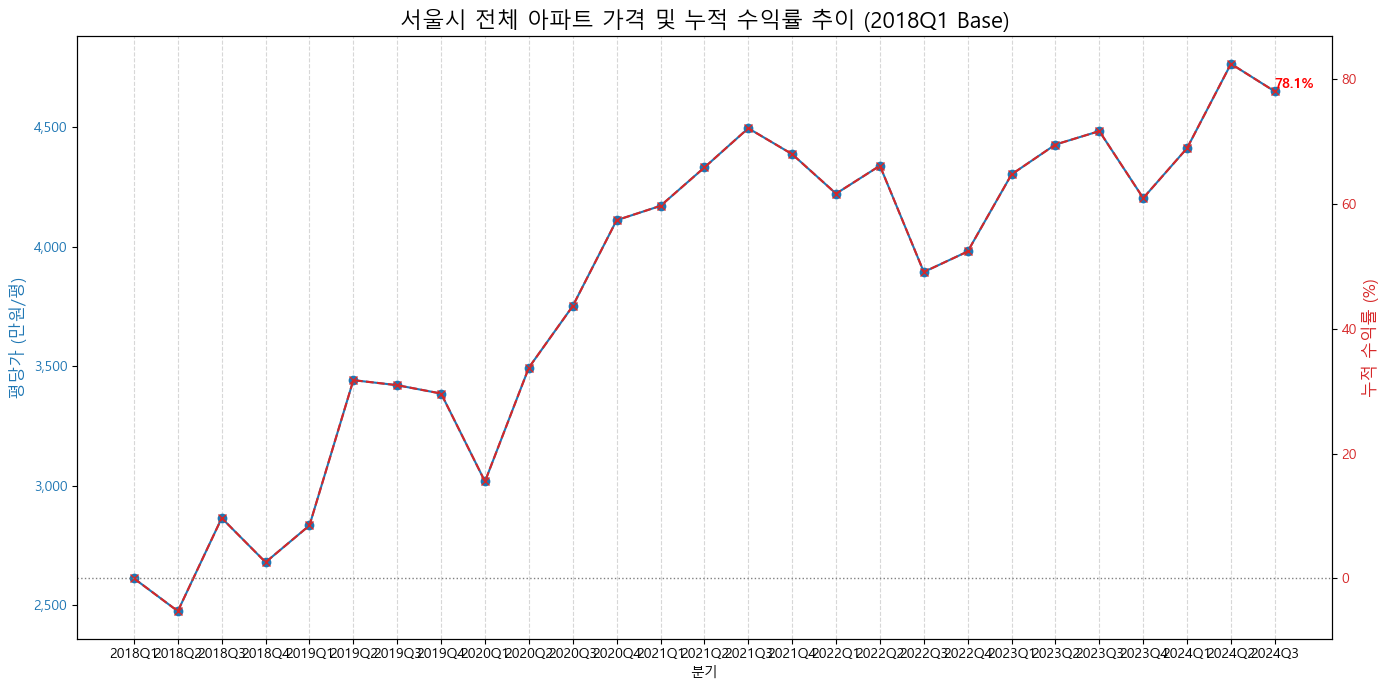

■ 서울시 전체 아파트 시장 흐름 요약
- 분석 기간: 27개 분기 (2018Q1 ~ 2024Q3)
- 시작 평당가: 2,611 만원
- 종료 평당가: 4,650 만원
- 서울시 전체 누적 수익률: 78.06%


In [42]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import pandas as pd

def visualize_seoul_total_trend(bldg_type, start_year, start_quarter, duration_quarters):
    """
    df 전역 변수에 'QUARTER'(예: 2018Q1), 'BLDG_USG', 'AMT_PER_PYEONG' 컬럼이 이미 존재한다고 가정
    """
    
    # 1. 분석 대상 기간 리스트 생성 (포맷: 2018Q1)
    target_quarters = []
    current_y, current_q = start_year, start_quarter
    
    for _ in range(duration_quarters + 1):
        target_quarters.append(f"{current_y}Q{current_q}")
        current_q += 1
        if current_q > 4:
            current_y += 1
            current_q = 1
            
    # 2. 데이터 필터링 및 집계
    # 이미 존재하는 'QUARTER' 컬럼을 사용하여 필터링
    mask = (df['BLDG_USG'] == bldg_type) & (df['QUARTER'].isin(target_quarters))
    
    filtered_df = df.loc[mask]
    
    if filtered_df.empty:
        print("해당 조건의 데이터가 없습니다.")
        return

    # 분기별 평단가 평균 계산 (Index: QUARTER, Value: AMT_PER_PYEONG)
    # reindex를 사용하여 원하는 기간 순서대로 정렬 (누락된 기간은 NaN 처리 후 dropna)
    price_series = filtered_df.groupby('QUARTER')['AMT_PER_PYEONG'].mean()
    price_series = price_series.reindex(target_quarters).dropna()

    if price_series.empty:
        print("기간 내 유효한 데이터가 없습니다.")
        return

    # 3. 수익률 계산 (시작 시점 대비)
    start_price = price_series.iloc[0]
    return_series = (price_series / start_price - 1) * 100
    
    # 4. 시각화
    fig, ax1 = plt.subplots(figsize=(14, 7))
    
    # (1) 평단가 그래프 (좌측 축)
    color_price = 'tab:blue'
    # 제목에 시작 분기 표시
    ax1.set_title(f"서울시 전체 {bldg_type} 가격 및 누적 수익률 추이 ({target_quarters[0]} Base)", fontsize=16)
    ax1.set_xlabel('분기')
    ax1.set_ylabel('평당가 (만원/평)', color=color_price, fontsize=12)
    
    ax1.plot(price_series.index, price_series.values, color=color_price, marker='o', label='평균 평당가')
    ax1.tick_params(axis='y', labelcolor=color_price)
    ax1.grid(True, axis='x', linestyle='--', alpha=0.5)
    
    # Y축 천단위 콤마 포맷
    ax1.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

    # (2) 수익률 그래프 (우측 축)
    ax2 = ax1.twinx()
    color_ret = 'tab:red'
    ax2.set_ylabel('누적 수익률 (%)', color=color_ret, fontsize=12) 
    
    ax2.plot(return_series.index, return_series.values, color=color_ret, linestyle='--', marker='x', label='누적 수익률')
    ax2.tick_params(axis='y', labelcolor=color_ret)
    
    # 0% 기준선
    ax2.axhline(0, color='gray', linestyle=':', linewidth=1)
    
    # 마지막 시점 수익률 텍스트 표시
    last_idx = return_series.index[-1]
    last_val = return_series.iloc[-1]
    ax2.text(last_idx, last_val, f"{last_val:.1f}%", color='red', fontweight='bold', va='bottom', ha='left')
    
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
    
    # 5. 결과 요약 출력
    print(f"■ 서울시 전체 {bldg_type} 시장 흐름 요약")
    print(f"- 분석 기간: {len(price_series)}개 분기 ({price_series.index[0]} ~ {price_series.index[-1]})")
    print(f"- 시작 평당가: {start_price:,.0f} 만원")
    print(f"- 종료 평당가: {price_series.iloc[-1]:,.0f} 만원")
    print(f"- 서울시 전체 누적 수익률: {last_val:.2f}%")

# 실행 예시
visualize_seoul_total_trend("아파트", 2018, 1, 26)

In [43]:
df

,Unnamed: 0.1,Unnamed: 0,CGG_CD,CGG_NM,STDG_CD,STDG_NM,BLDG_NM,CTRT_DAY,THING_AMT,ARCH_AREA,...,RGHT_SE,ARCH_YR,BLDG_USG,DCLR_SE,CTRT_YEAR,QUARTER,QUARTER_INT,CTRT_BLDG_AGE,AMT_PER_AREA,AMT_PER_PYEONG
0,0,14,11530,구로구,10800,오류동,NaN,2018-12-31,73000,197.40,...,NaN,1990,단독다가구,NaN,2018,2018Q4,12,28,369.807497,1222.509625
1,1,16,11215,광진구,10100,중곡동,NaN,2018-12-31,102000,89.09,...,NaN,1973,단독다가구,NaN,2018,2018Q4,12,45,1144.909642,3784.842294
2,2,43,11560,영등포구,10900,영등포동8가,NaN,2018-12-29,88700,36.36,...,NaN,1945,단독다가구,NaN,2018,2018Q4,12,73,2439.493949,8064.479098
3,3,87,11230,동대문구,10900,휘경동,NaN,2018-12-28,95000,140.22,...,NaN,1991,단독다가구,NaN,2018,2018Q4,12,27,677.506775,2239.701897
4,4,92,11620,관악구,10200,신림동,NaN,2018-12-27,56500,179.46,...,NaN,1988,단독다가구,NaN,2018,2018Q4,12,30,314.833389,1040.776218
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
417522,417522,833589,11350,노원구,10300,공릉동,삼익아파트,2023-11-25,63500,84.77,...,NaN,1997,아파트,중개거래,2023,2023Q4,11,26,749.085761,2476.327710
417523,417523,833592,11590,동작구,10800,대방동,신한토탈,2023-11-24,67500,69.12,...,NaN,1997,아파트,중개거래,2023,2023Q4,11,26,976.562500,3228.320312
417524,417524,833593,11440,마포구,12500,성산동,월드컵아이파크(667),2023-11-23,105000,117.95,...,NaN,2009,아파트,중개거래,2023,2023Q4,11,14,890.207715,2942.848665
417525,417525,833597,11440,마포구,12600,중동,백명TRENDYAPT,2023-11-11,76000,107.48,...,NaN,2004,아파트,중개거래,2023,2023Q4,11,19,707.108299,2337.558616
